In [22]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.46,0.0,23.38,8.37,0


In [24]:
df.columns.tolist()

['Year',
 'Import',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [25]:
df.isna().mean() * 100

Year                                            0.0
Import                                          0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule 

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Import                                        34 non-null     float64
 2   Gross National Savings                        34 non-null     float64
 3   Government Debt                               34 non-null     float64
 4   Natural Gas Production                        34 non-null     float64
 5   Iron Ore Production                           34 non-null     float64
 6   Inbound Foreign Direct Investment             34 non-null     float64
 7   Natural Population Growth                     34 non-null     float64
 8   Government Budget Revenues                    34 non-null     float64
 9   Coal Imports                                  34 non-null     float

In [27]:
df = df.rename(columns={"Year": "Date"})

## 1. ипц

### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [28]:
df["Consumer Price Inflation"].describe().round(3)

count    34.000
mean      8.661
std       2.925
min       5.110
25%       6.818
50%       8.360
75%       8.660
max      17.150
Name: Consumer Price Inflation, dtype: float64

Text(0.5, 1.0, 'Dynamics of Consumer Price Inflation in Kazakhstan')

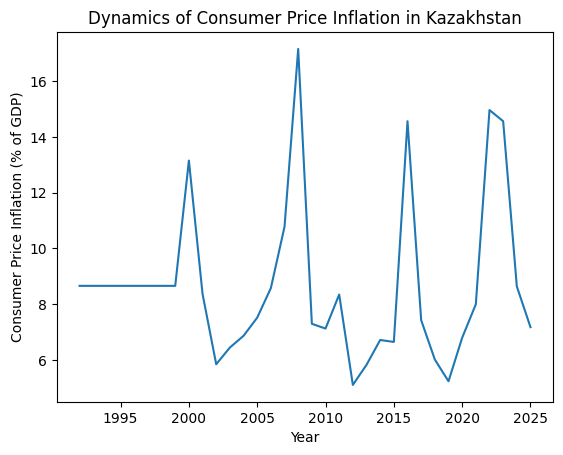

In [29]:
plt.figure()
plt.plot(df["Date"], df["Consumer Price Inflation"])
plt.xlabel("Year")
plt.ylabel("Consumer Price Inflation (% of GDP)")
plt.title("Dynamics of Consumer Price Inflation in Kazakhstan")

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [30]:
df["Average Annual Exchange Rate to USD"].describe().round(3)

count     34.000
mean     207.420
std      128.278
min       35.540
25%      127.788
50%      149.345
75%      299.932
max      468.960
Name: Average Annual Exchange Rate to USD, dtype: float64

Text(0.5, 1.0, 'Dynamics of Average Annual Exchange Rate to USD in Kazakhstan')

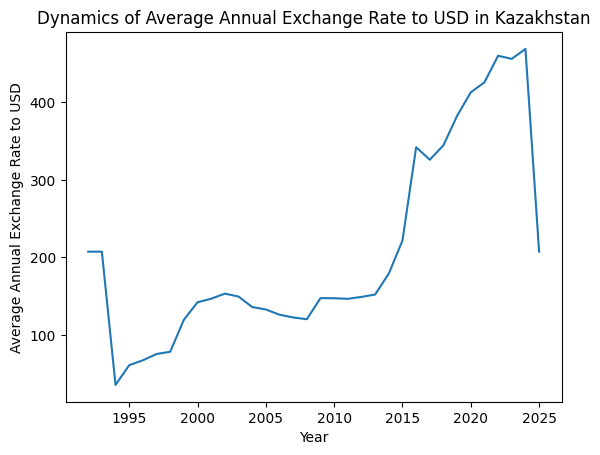

In [31]:
plt.figure()
plt.plot(df["Date"], df["Average Annual Exchange Rate to USD"])
plt.xlabel("Year")
plt.ylabel("Average Annual Exchange Rate to USD")
plt.title("Dynamics of Average Annual Exchange Rate to USD in Kazakhstan")

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

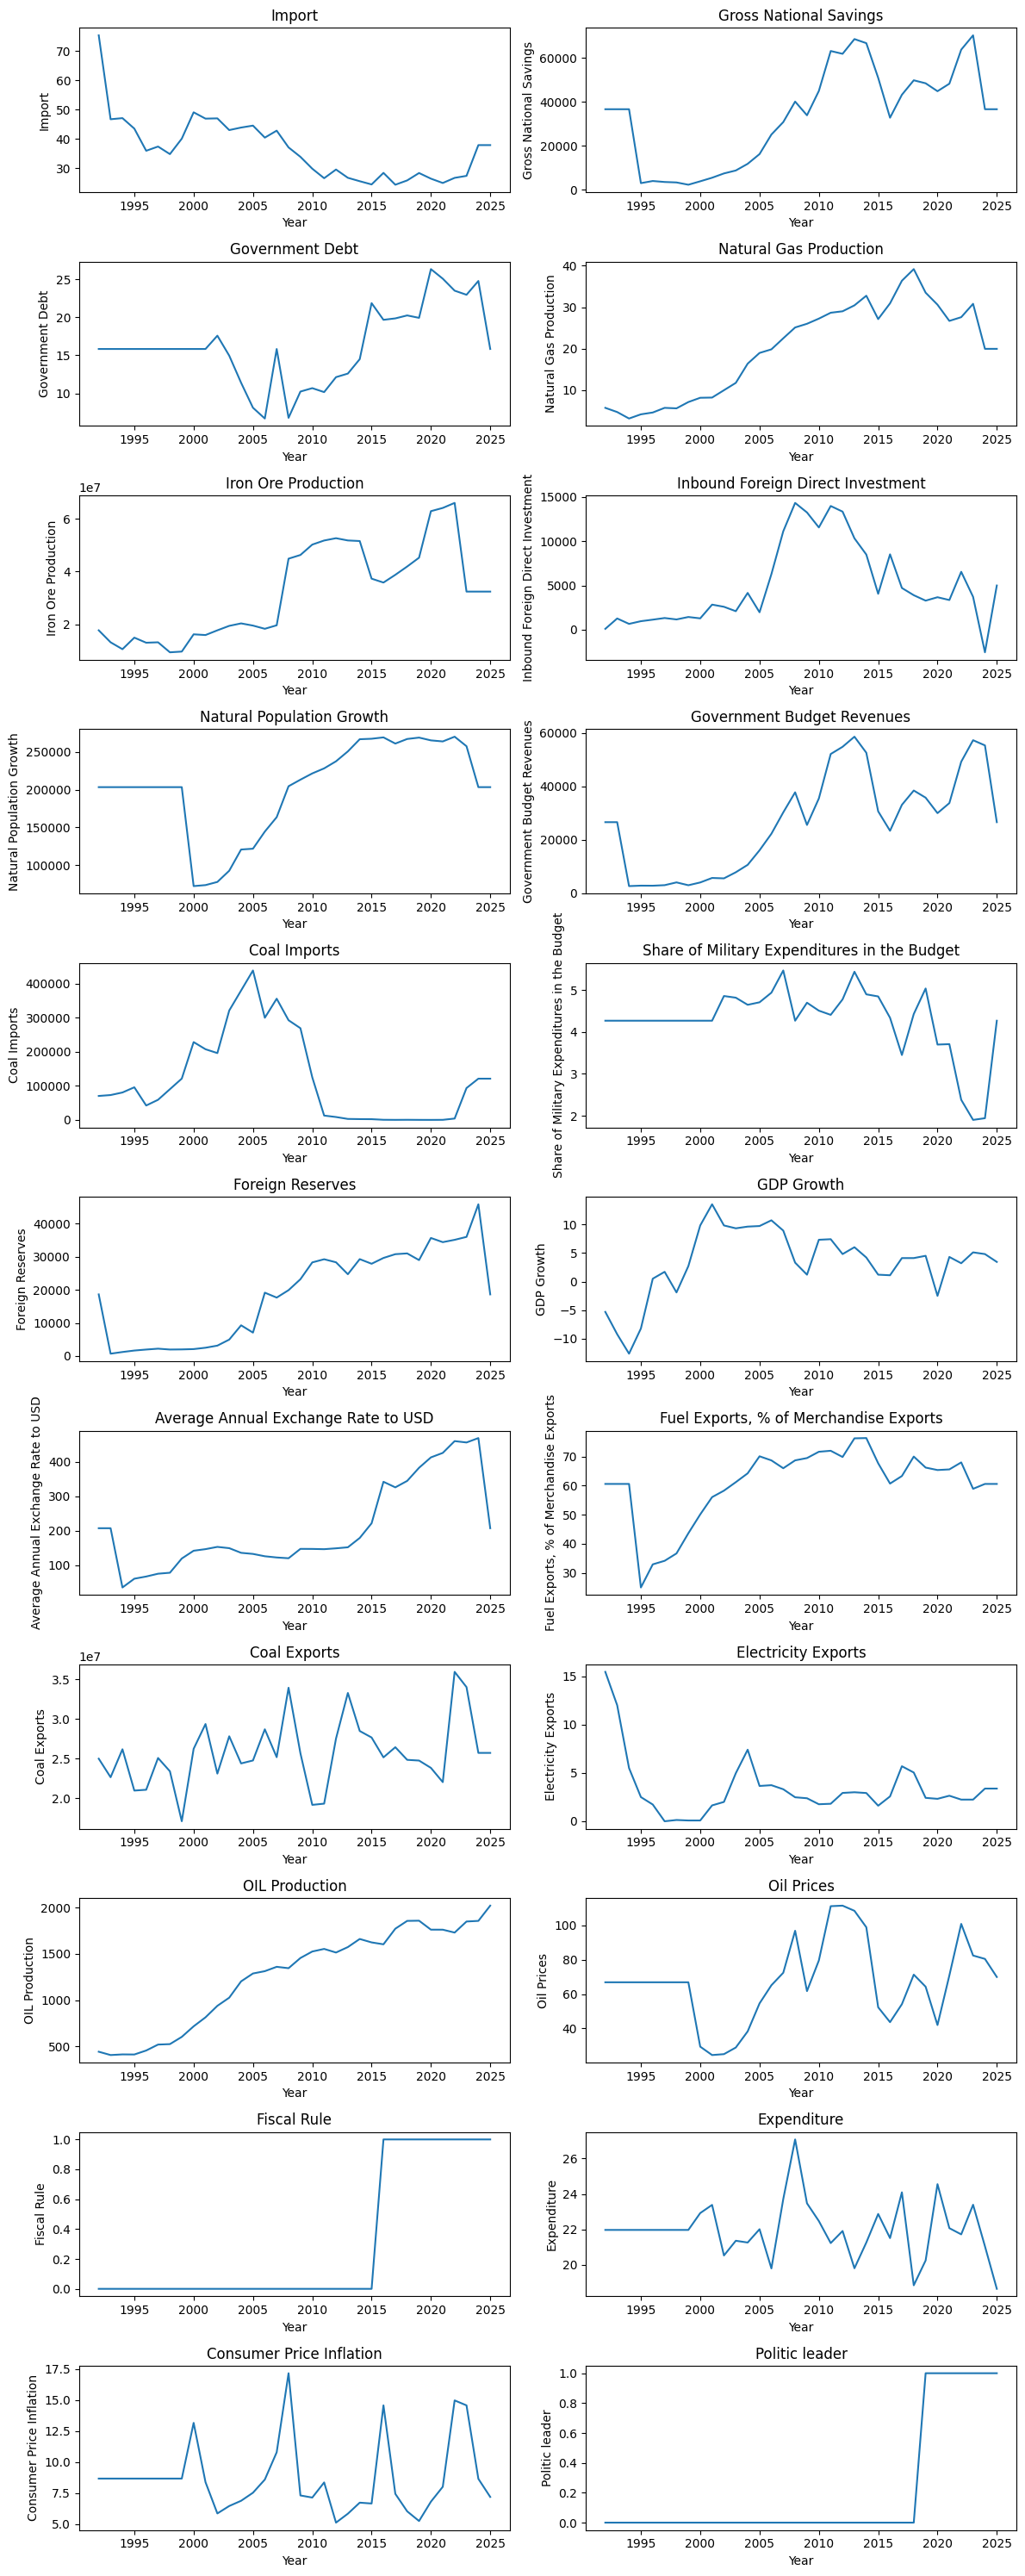

In [32]:
vars_to_plot = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

fig, axes = plt.subplots(11, 2, figsize=(12, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

In [34]:
df.describe().round(2)

,Date,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,36.53,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72,3.43,207.42,60.61,25723621.19,3.38,1257.72,66.89,0.29,21.97,8.66,0.21
std,9.96,10.65,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14,5.89,128.28,12.54,4220621.13,3.11,533.55,23.62,0.46,1.62,2.93,0.41
min,1992.00,24.43,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00,-12.60,35.54,24.99,17097980.00,0.00,408.00,24.46,0.00,18.65,5.11,0.00
25%,2000.25,26.96,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75,1.20,127.79,59.35,23510567.50,1.86,742.25,54.23,0.00,21.26,6.82,0.00
50%,2008.50,36.58,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00,4.15,149.35,63.80,25170530.50,2.54,1407.50,66.89,0.00,21.97,8.36,0.00
75%,2016.75,43.42,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25,7.38,299.93,68.72,27631718.00,3.58,1712.07,77.82,1.00,22.77,8.66,0.00
max,2025.00,75.33,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00,13.50,468.96,76.39,35948140.00,15.45,2019.86,111.57,1.00,27.07,17.15,1.00


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

 # Как варик брать не все-все переменные, а с самой большой корреляцыей по модулю

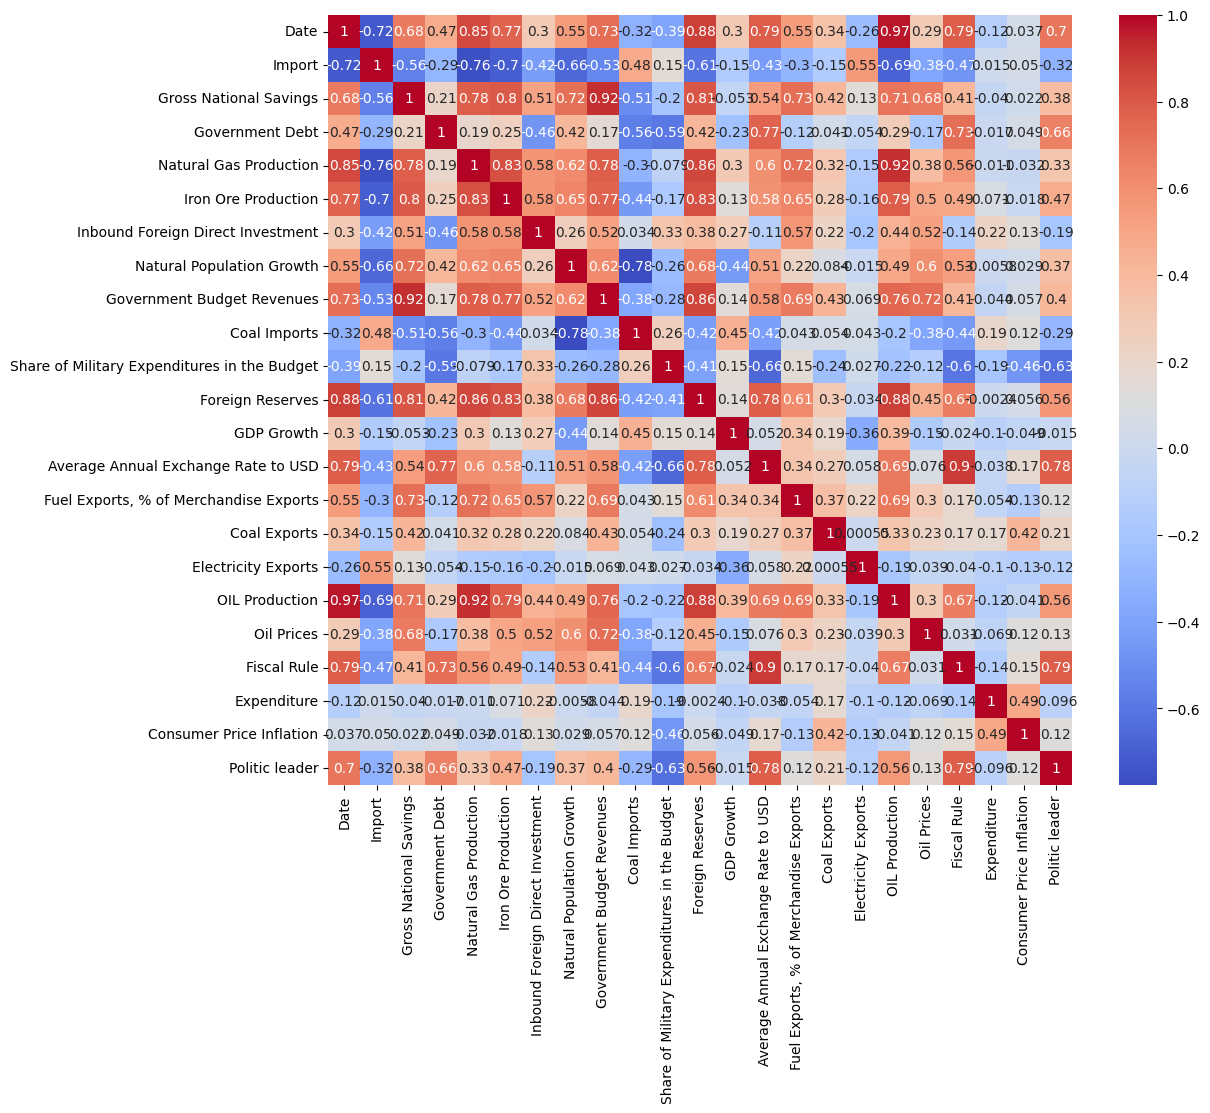

In [35]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [36]:
y = df["Consumer Price Inflation"]

X = df[[
    "Import",
    "Gross National Savings",
    "Government Debt",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "GDP Growth",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",
    "Fiscal Rule",
    "Expenditure",
    "Politic leader"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Consumer Price Inflation   R-squared:                       0.855
Model:                                  OLS   Adj. R-squared:                  0.600
Method:                       Least Squares   F-statistic:                     3.356
Date:                      Sat, 29 Nov 2025   Prob (F-statistic):             0.0173
Time:                              23:46:47   Log-Likelihood:                -51.462
No. Observations:                        34   AIC:                             146.9
Df Residuals:                            12   BIC:                             180.5
Df Model:                                21                                         
Covariance Type:                  nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                          -19.2862     13.810     -1.397      0.188     -49.376      10.803
Import                                           0.0889      0.106      0.840      0.417      -0.142       0.319
Gross National Savings                           0.0003      0.000      2.130      0.055   -6.29e-06       0.001
Government Debt                                 -0.3776      0.231     -1.632      0.129      -0.882       0.127
Natural Gas Production                          -0.6492      0.316     -2.052      0.063      -1.338       0.040
Iron Ore Production                           1.914e-09   8.36e-08      0.023      0.982    -1.8e-07    1.84e-07
Inbound Foreign Direct Investment                0.0002      0.000      0.935      0.368      -0.000       0.001
Natural Population Growth                     7.931e-06   3.94e-05      0.201      0.844    -7.8e-05    9.38e-05
Government Budget Revenues                      -0.0002      0.000     -0.962      0.355      -0.001       0.000
Coal Imports                                  1.626e-05   1.29e-05      1.263      0.231   -1.18e-05    4.43e-05
Share of Military Expenditures in the Budget     1.7064      1.559      1.095      0.295      -1.691       5.103
Foreign Reserves                              1.782e-05      0.000      0.140      0.891      -0.000       0.000
GDP Growth                                       0.0730      0.195      0.374      0.715      -0.352       0.498
Average Annual Exchange Rate to USD              0.0506      0.024      2.144      0.053      -0.001       0.102
Fuel Exports, % of Merchandise Exports          -0.1962      0.124     -1.580      0.140      -0.467       0.074
Coal Exports                                  1.435e-07   1.09e-07      1.314      0.213   -9.44e-08    3.82e-07
Electricity Exports                             -0.6510      0.301     -2.162      0.052      -1.307       0.005
OIL Production                                   0.0039      0.006      0.681      0.509      -0.009       0.016
Oil Prices                                       0.0559      0.089      0.630      0.540      -0.137       0.249
Fiscal Rule                                      6.9441      5.580      1.245      0.237      -5.213      19.102
Expenditure                                      0.8080      0.429      1.882      0.084      -0.127       1.743
Politic leader                                 -10.5789      4.208     -2.514      0.027     -19.747      -1.410
==============================================================================
Omnibus:                        0.489   Durbin-Watson:                   2.807
Prob(Omnibus):                  0.

In [39]:
model.params.round(5)

const                                          -19.28622
Import                                           0.08888
Gross National Savings                           0.00027
Government Debt                                 -0.37758
Natural Gas Production                          -0.64916
Iron Ore Production                              0.00000
Inbound Foreign Direct Investment                0.00022
Natural Population Growth                        0.00001
Government Budget Revenues                      -0.00016
Coal Imports                                     0.00002
Share of Military Expenditures in the Budget     1.70645
Foreign Reserves                                 0.00002
GDP Growth                                       0.07296
Average Annual Exchange Rate to USD              0.05058
Fuel Exports, % of Merchandise Exports          -0.19620
Coal Exports                                     0.00000
Electricity Exports                             -0.65097
OIL Production                 

In [42]:
p = model.pvalues

significant = [var for var in p.index if p[var] < 0.10]
nonsignificant = [var for var in p.index if p[var] >= 0.10]

print("Значимые переменные:", significant)
print("Незначимые переменные:", nonsignificant)


Значимые переменные: ['Gross National Savings', 'Natural Gas Production', 'Average Annual Exchange Rate to USD', 'Electricity Exports', 'Expenditure', 'Politic leader']
Незначимые переменные: ['const', 'Import', 'Government Debt', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Share of Military Expenditures in the Budget', 'Foreign Reserves', 'GDP Growth', 'Fuel Exports, % of Merchandise Exports', 'Coal Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule']


также, построим 95% доверительные интервалы для всех коэффициентов:

In [44]:
conf = model.conf_int(alpha=0.05)

significant_ci = []
nonsignificant_ci = []

for var in conf.index:
    low, high = conf.loc[var]
    if low > 0 or high < 0:      # интервал не содержит ноль
        significant_ci.append(var)
    else:
        nonsignificant_ci.append(var)

print("Значимые по доверительным интервалам:", significant_ci)
print("Незначимые по доверительным интервалам:", nonsignificant_ci)

Значимые по доверительным интервалам: ['Politic leader']
Незначимые по доверительным интервалам: ['const', 'Import', 'Gross National Savings', 'Government Debt', 'Natural Gas Production', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Share of Military Expenditures in the Budget', 'Foreign Reserves', 'GDP Growth', 'Average Annual Exchange Rate to USD', 'Fuel Exports, % of Merchandise Exports', 'Coal Exports', 'Electricity Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule', 'Expenditure']


### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [50]:
model_robust = model.get_robustcov_results(cov_type="HC3")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)

Значимые (robust): []
Незначимые (robust): ['const', 'Import', 'Gross National Savings', 'Government Debt', 'Natural Gas Production', 'Iron Ore Production', 'Inbound Foreign Direct Investment', 'Natural Population Growth', 'Government Budget Revenues', 'Coal Imports', 'Share of Military Expenditures in the Budget', 'Foreign Reserves', 'GDP Growth', 'Average Annual Exchange Rate to USD', 'Fuel Exports, % of Merchandise Exports', 'Coal Exports', 'Electricity Exports', 'OIL Production', 'Oil Prices', 'Fiscal Rule', 'Expenditure', 'Politic leader']


#### 2 способ: Мультиколлинеарность (VIF)

In [46]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,const,1893.876135
1,Import,12.235939
2,Gross National Savings,77.427637
3,Government Debt,13.329964
4,Natural Gas Production,120.171605
5,Iron Ore Production,21.133643
6,Inbound Foreign Direct Investment,10.824442
7,Natural Population Growth,56.468074
8,Government Budget Revenues,96.343121
9,Coal Imports,26.972450


# это хуево

#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [54]:
y = df["Consumer Price Inflation"]

control_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',
    'Expenditure',
    'Politic leader'
]

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset + ["Average Annual Exchange Rate to USD"]])).fit()
    coef = model.params.get("Average Annual Exchange Rate to USD", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "FiscalRule coefficient"])


,Removed variable,FiscalRule coefficient
0,Import,Average Annual Exchange Rate to USD 0.03491...
1,Gross National Savings,Average Annual Exchange Rate to USD 0.02121...
2,Government Debt,Average Annual Exchange Rate to USD 0.02310...
3,Natural Gas Production,Average Annual Exchange Rate to USD 0.02150...
4,Iron Ore Production,Average Annual Exchange Rate to USD 0.03301...
5,Inbound Foreign Direct Investment,Average Annual Exchange Rate to USD 0.03846...
6,Natural Population Growth,Average Annual Exchange Rate to USD 0.03041...
7,Government Budget Revenues,Average Annual Exchange Rate to USD 0.01842...
8,Coal Imports,Average Annual Exchange Rate to USD 0.03303...
9,Share of Military Expenditures in the Budget,Average Annual Exchange Rate to USD 0.02712...


### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

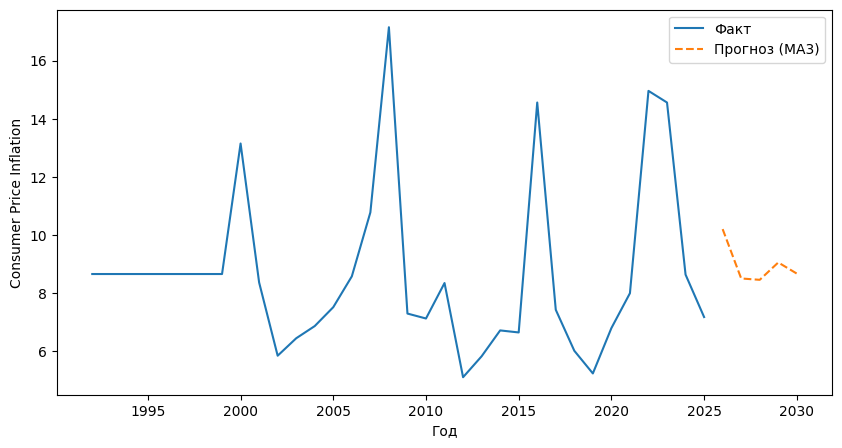

In [55]:
X_vars = [
    'Import',
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'GDP Growth',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',
    'Expenditure',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Consumer Price Inflation"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Consumer Price Inflation")
plt.legend()
plt.show()